# Análise das Recomendações Geradas pelo Modelo CBF

Análise completa dos filmes recomendados (diretório `filmes_recomendados_users/`) cruzados com:
- **Catálogo** (`cbf_df.csv`) — metadados dos filmes
- **Treino** (`training.csv`) — popularidade real no dataset

Objetivo principal: identificar **vieses de popularidade**, diversidade de gênero e qualidade das recomendações para ajuste do modelo.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

REC_DIR      = Path('filmes_recomendados_users')
CBF_PATH     = 'data/cbf_df.csv'
TRAINING_PATH = 'data_spliting/training.csv'

## 1. Carregamento dos dados

In [38]:
# --- Recomendações: concatenar todos os CSVs ---
rec_frames = []
for f in sorted(REC_DIR.glob('user*.csv')):
    uid = int(f.stem.replace('user', ''))
    tmp = pd.read_csv(f, index_col=0)
    tmp['userId'] = uid
    rec_frames.append(tmp)

rec = pd.concat(rec_frames, ignore_index=True)
rec.columns = rec.columns.str.strip()

# --- Catálogo e treino ---
cbf = pd.read_csv(CBF_PATH, usecols=[
    'movie_id', 'title', 'genres', 'year',
    'tmdb_rating', 'tmdb_votes', 'imdb_rating', 'imdb_votes', 'director'
])
train = pd.read_csv(TRAINING_PATH)

# Popularidade no treino (nº de ratings por filme)
popularity = train.groupby('movieId')['rating'].agg(
    n_ratings='count', avg_rating='mean'
).reset_index().rename(columns={'movieId': 'movie_id'})

print(f'Recomendações carregadas : {len(rec):,} linhas')
print(f'Usuários com recomendação: {rec["userId"].nunique():,}')
print(f'Filmes únicos recomen.   : {rec["movie_id"].nunique():,}')
rec.head(4)

Recomendações carregadas : 6,080 linhas
Usuários com recomendação: 608
Filmes únicos recomen.   : 1,053


,movie_id,title,score_recomendacao,userId
0,27036,Merlin (1998),0.998970,1
1,26849,"Stand, The (1994)",0.994541,1
2,26887,"Langoliers, The (1995)",0.992171,1
3,130842,Power/Rangers (2015),0.989493,1


In [39]:
# Merge recomendações com metadados e popularidade
rec_full = (
    rec
    .merge(cbf, on='movie_id', how='left')
    .merge(popularity, on='movie_id', how='left')
)

# Filmes do catálogo enriquecidos com popularidade (para comparação)
catalog_pop = cbf.merge(popularity, on='movie_id', how='left')
catalog_pop['n_ratings'] = catalog_pop['n_ratings'].fillna(0)
catalog_pop['is_recommended'] = catalog_pop['movie_id'].isin(rec['movie_id'].unique())

print(f'Rec com metadados: {len(rec_full):,} linhas')
rec_full[['userId','movie_id','title_x','score_recomendacao','genres','n_ratings']].head(4)

Rec com metadados: 6,080 linhas


,userId,movie_id,title_x,score_recomendacao,genres,n_ratings
0,1,27036,Merlin (1998),0.998970,Action|Adventure|Drama|Fantasy|Romance,NaN
1,1,26849,"Stand, The (1994)",0.994541,Adventure|Drama|Fantasy|Horror|Sci-Fi,1.0
2,1,26887,"Langoliers, The (1995)",0.992171,Drama|Fantasy|Horror|Mystery|Sci-Fi|Thriller,NaN
3,1,130842,Power/Rangers (2015),0.989493,Action|Adventure|Sci-Fi,1.0


In [40]:
# Renomear coluna de título (pode existir title_x após merge duplo)
if 'title_x' in rec_full.columns:
    rec_full = rec_full.rename(columns={'title_x': 'title'})
    rec_full = rec_full.drop(columns=[c for c in rec_full.columns if c == 'title_y'], errors='ignore')

# Explode gêneros para análises por gênero
rec_genres = rec_full.dropna(subset=['genres']).copy()
rec_genres = rec_genres.assign(genre=rec_genres['genres'].str.split('|')).explode('genre')
rec_genres['genre'] = rec_genres['genre'].str.strip()

print('Colunas disponíveis:', rec_full.columns.tolist())

Colunas disponíveis: ['movie_id', 'title', 'score_recomendacao', 'userId', 'genres', 'year', 'tmdb_rating', 'tmdb_votes', 'imdb_rating', 'imdb_votes', 'director', 'n_ratings', 'avg_rating']


---
## 2. Visão Geral das Recomendações

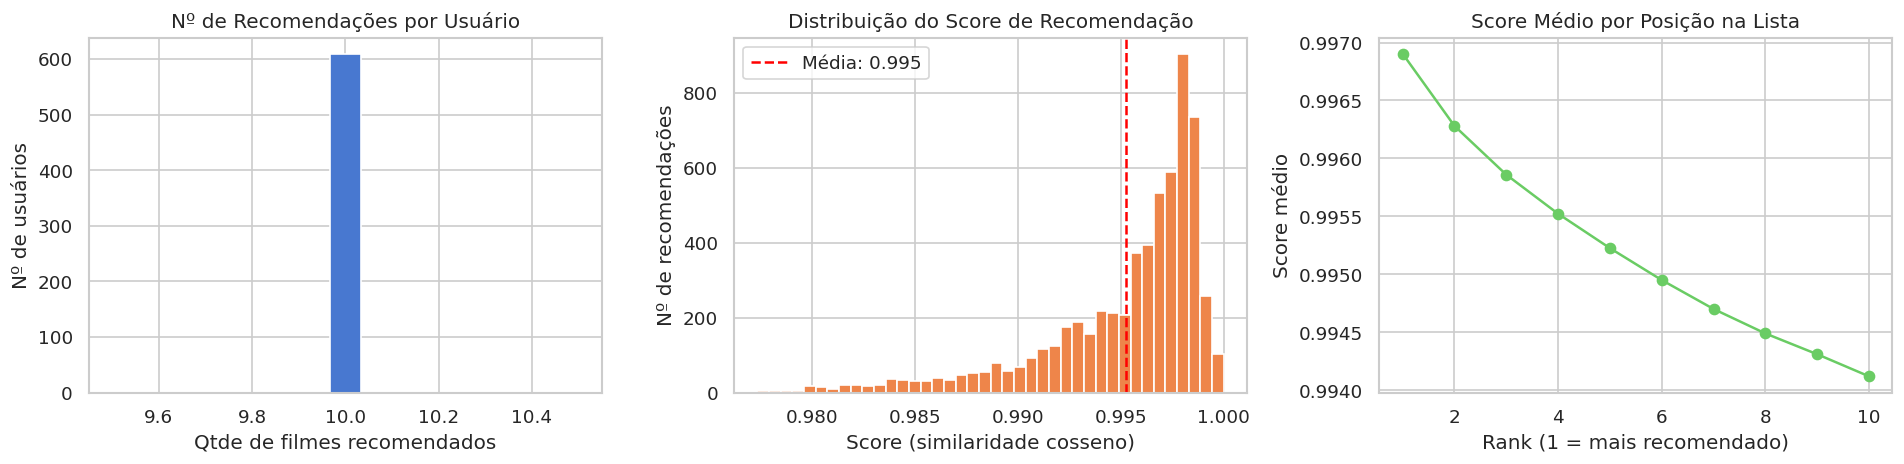

In [41]:
recs_per_user = rec.groupby('userId')['movie_id'].count()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 2.1 Nº de recomendações por usuário
axes[0].hist(recs_per_user, bins=15, color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_title('Nº de Recomendações por Usuário')
axes[0].set_xlabel('Qtde de filmes recomendados')
axes[0].set_ylabel('Nº de usuários')

# 2.2 Distribuição do score de recomendação
axes[1].hist(rec['score_recomendacao'], bins=40, color=sns.color_palette('muted')[1], edgecolor='white')
axes[1].axvline(rec['score_recomendacao'].mean(), color='red', linestyle='--',
                label=f'Média: {rec["score_recomendacao"].mean():.3f}')
axes[1].set_title('Distribuição do Score de Recomendação')
axes[1].set_xlabel('Score (similaridade cosseno)')
axes[1].set_ylabel('Nº de recomendações')
axes[1].legend()

# 2.3 Score por posição na lista (rank 1 a N)
rec['rank'] = rec.groupby('userId')['score_recomendacao'].rank(ascending=False, method='first').astype(int)
score_by_rank = rec.groupby('rank')['score_recomendacao'].mean()
axes[2].plot(score_by_rank.index, score_by_rank.values, marker='o', color=sns.color_palette('muted')[2])
axes[2].set_title('Score Médio por Posição na Lista')
axes[2].set_xlabel('Rank (1 = mais recomendado)')
axes[2].set_ylabel('Score médio')

plt.tight_layout()
plt.show()

---
## 3. Popularidade dos Filmes Recomendados
> **Viés de popularidade**: o modelo tende a recomendar filmes muito populares (já muito avaliados) ou consegue diversificar?

/tmp/ipykernel_17539/454688570.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pop_compare, x='Grupo', y='Popularidade (n_ratings)',


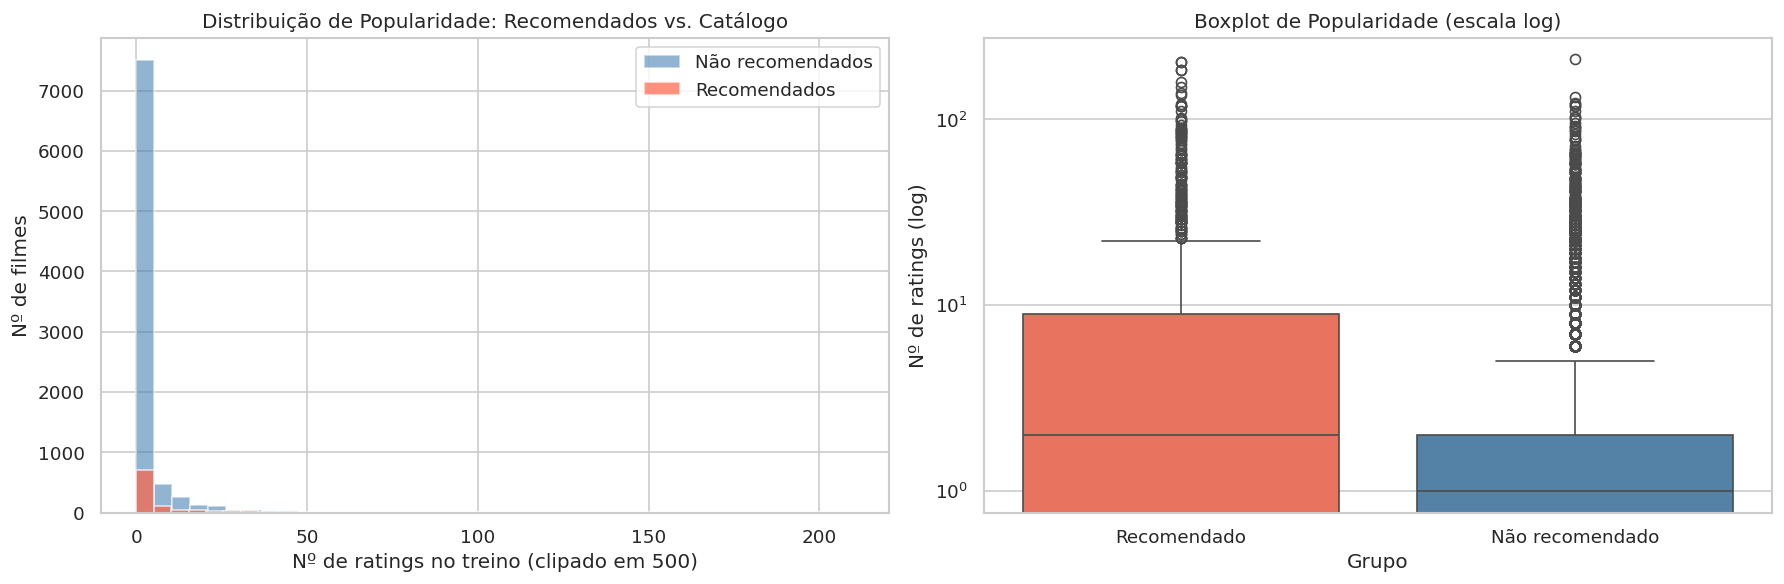


                                  Recomendados   Não recomendados
Média de ratings                          10.6                3.2
Mediana de ratings                         2.0                1.0
Filmes sem nenhum rating                   299               3648
% filmes com 0 ratings                   28.4%              42.1%


In [42]:
# 3.1 Distribuição de popularidade (n_ratings) — Recomendados vs. Não recomendados
rec_pop    = catalog_pop[catalog_pop['is_recommended']]['n_ratings']
nonrec_pop = catalog_pop[~catalog_pop['is_recommended']]['n_ratings']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
axes[0].hist(nonrec_pop.clip(upper=500), bins=40, alpha=0.6, label='Não recomendados', color='steelblue', edgecolor='white')
axes[0].hist(rec_pop.clip(upper=500), bins=40, alpha=0.7, label='Recomendados', color='tomato', edgecolor='white')
axes[0].set_title('Distribuição de Popularidade: Recomendados vs. Catálogo')
axes[0].set_xlabel('Nº de ratings no treino (clipado em 500)')
axes[0].set_ylabel('Nº de filmes')
axes[0].legend()

# Boxplot comparativo
pop_compare = pd.DataFrame({
    'Popularidade (n_ratings)': pd.concat([rec_pop, nonrec_pop]),
    'Grupo': ['Recomendado'] * len(rec_pop) + ['Não recomendado'] * len(nonrec_pop)
})
sns.boxplot(data=pop_compare, x='Grupo', y='Popularidade (n_ratings)',
            palette=['tomato', 'steelblue'], ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Boxplot de Popularidade (escala log)')
axes[1].set_ylabel('Nº de ratings (log)')

plt.tight_layout()
plt.show()

print(f"\n{'':30s} {'Recomendados':>15s} {'Não recomendados':>18s}")
print(f"{'Média de ratings':30s} {rec_pop.mean():>15.1f} {nonrec_pop.mean():>18.1f}")
print(f"{'Mediana de ratings':30s} {rec_pop.median():>15.1f} {nonrec_pop.median():>18.1f}")
print(f"{'Filmes sem nenhum rating':30s} {(rec_pop==0).sum():>15d} {(nonrec_pop==0).sum():>18d}")
print(f"{'% filmes com 0 ratings':30s} {(rec_pop==0).mean()*100:>14.1f}% {(nonrec_pop==0).mean()*100:>17.1f}%")

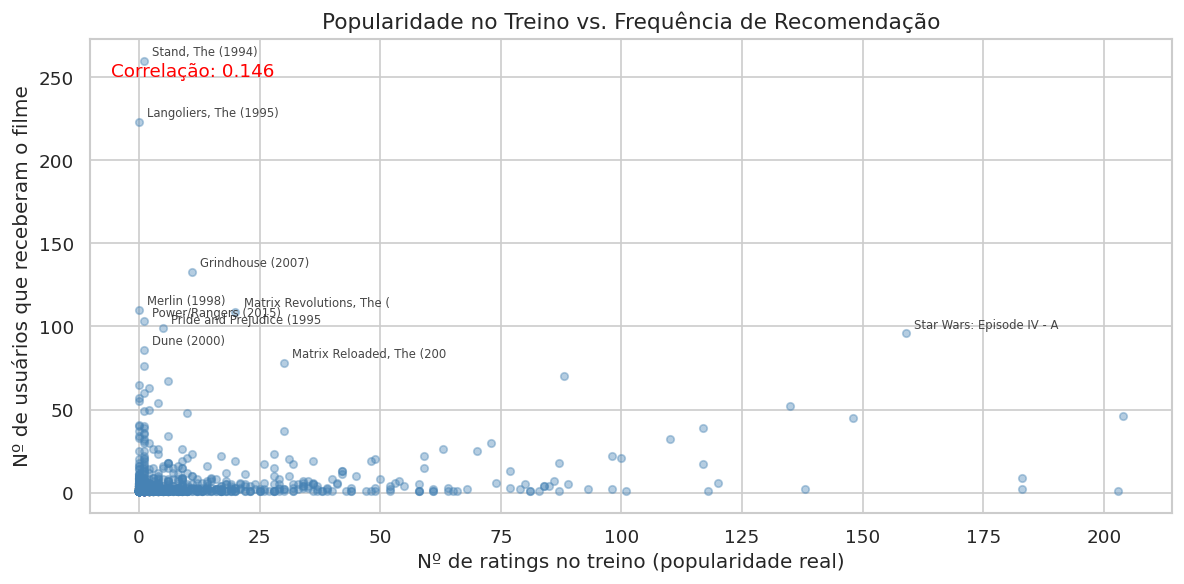

Correlação popularidade × frequência de recomendação: 0.146
Correlação baixa — modelo diversifica bem além dos filmes populares.


In [43]:
# 3.2 Popularidade por frequência de aparição nas recomendações
rec_freq = (
    rec_full.groupby('movie_id')
    .agg(
        n_users_recommended=('userId', 'nunique'),
        avg_score=('score_recomendacao', 'mean'),
        title=('title', 'first'),
        n_ratings=('n_ratings', 'first')
    )
    .reset_index()
    .sort_values('n_users_recommended', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    rec_freq['n_ratings'].fillna(0),
    rec_freq['n_users_recommended'],
    alpha=0.4, s=20, color='steelblue'
)
ax.set_title('Popularidade no Treino vs. Frequência de Recomendação', fontsize=13)
ax.set_xlabel('Nº de ratings no treino (popularidade real)')
ax.set_ylabel('Nº de usuários que receberam o filme')

# Destaque top 10 mais recomendados
top10 = rec_freq.head(10)
for _, row in top10.iterrows():
    ax.annotate(
        row['title'][:25], 
        xy=(row['n_ratings'] if pd.notna(row['n_ratings']) else 0, row['n_users_recommended']),
        fontsize=7, alpha=0.85,
        xytext=(5, 3), textcoords='offset points'
    )

corr = rec_freq[['n_ratings', 'n_users_recommended']].dropna().corr().iloc[0, 1]
ax.text(0.02, 0.95, f'Correlação: {corr:.3f}', transform=ax.transAxes,
        fontsize=11, color='red', va='top')
plt.tight_layout()
plt.show()

print(f'Correlação popularidade × frequência de recomendação: {corr:.3f}')
if corr > 0.5:
    print('⚠ Correlação alta — modelo pode ter viés de popularidade.')
elif corr > 0.3:
    print('Correlação moderada — algum viés de popularidade presente.')
else:
    print('Correlação baixa — modelo diversifica bem além dos filmes populares.')

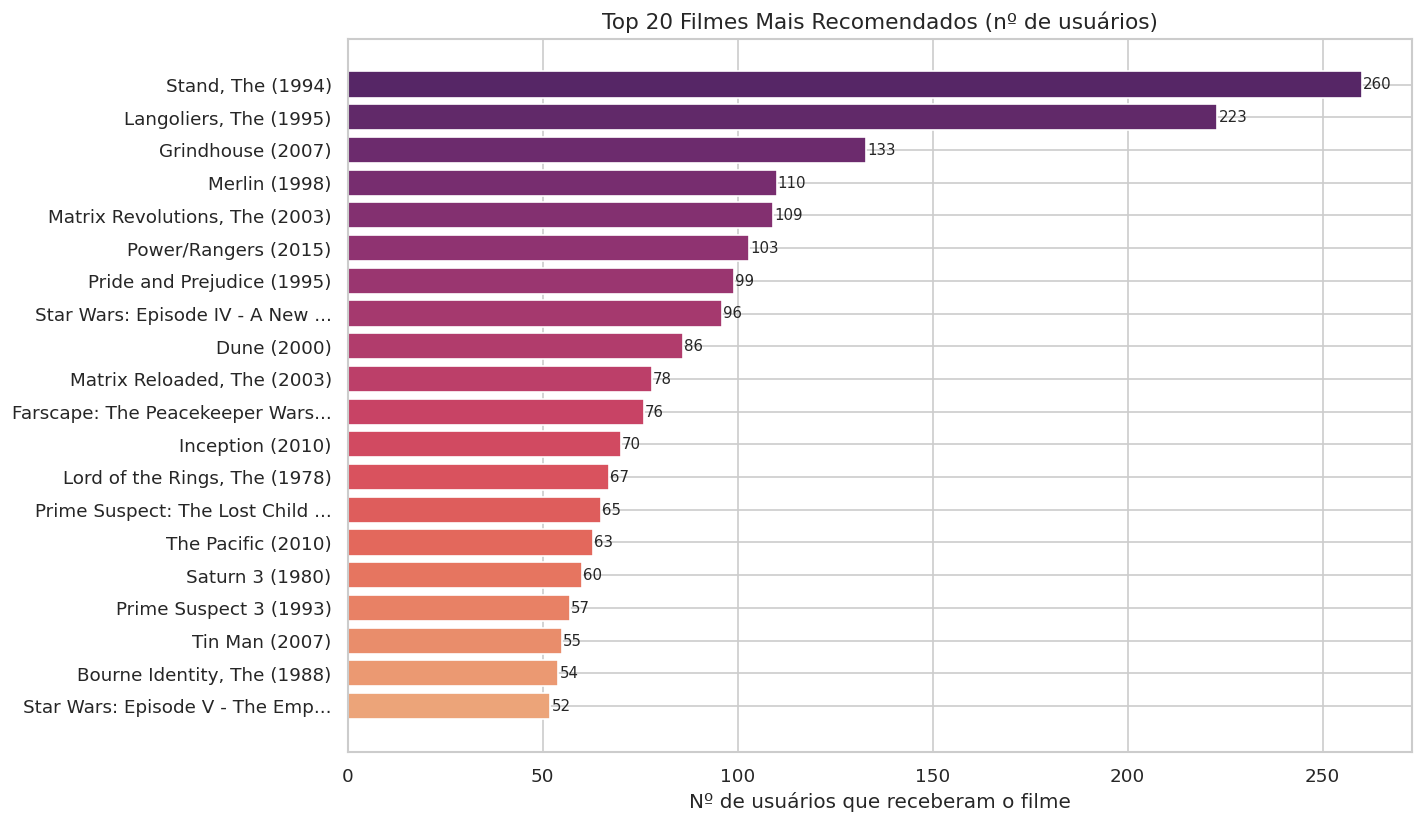

In [44]:
# 3.3 Filmes mais recomendados (top 20)
top_rec = rec_freq.head(20).copy()
top_rec['label'] = top_rec['title'].apply(lambda t: (t[:30] + '...') if len(str(t)) > 30 else t)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    top_rec['label'][::-1],
    top_rec['n_users_recommended'][::-1],
    color=sns.color_palette('flare', 20)
)
ax.set_title('Top 20 Filmes Mais Recomendados (nº de usuários)', fontsize=13)
ax.set_xlabel('Nº de usuários que receberam o filme')
for bar, val in zip(bars, top_rec['n_users_recommended'][::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

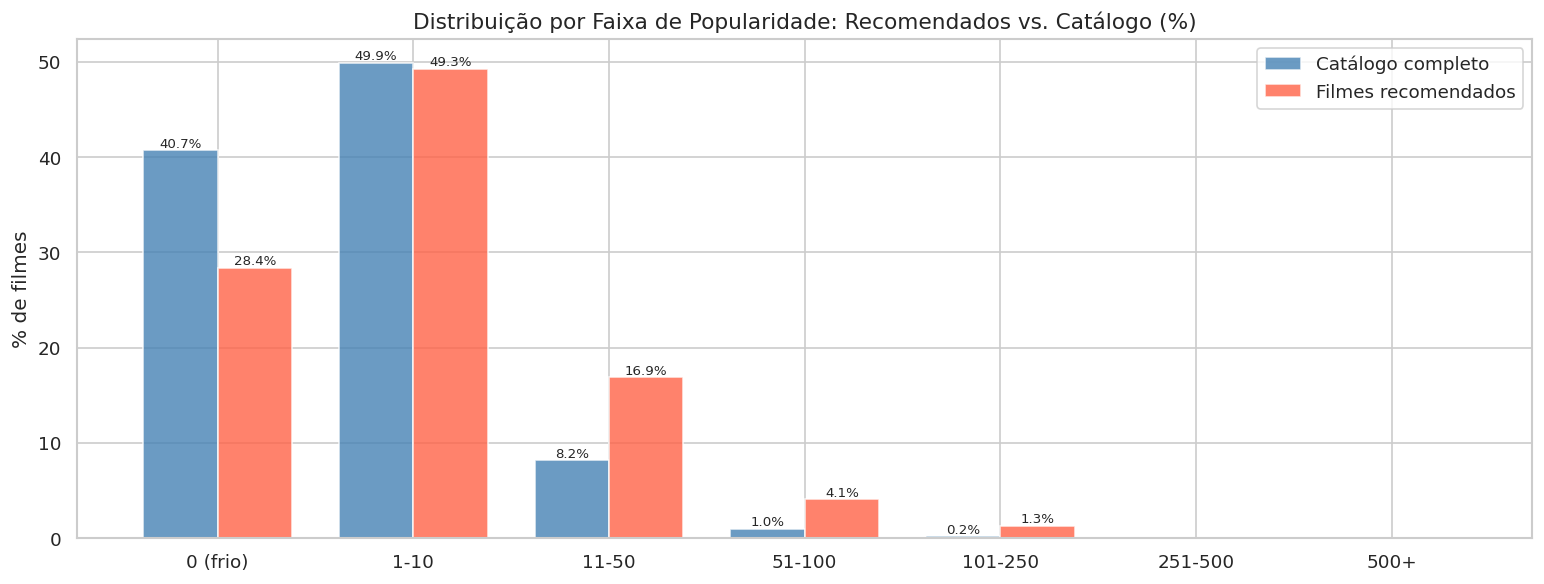


Faixa de popularidade | % no catálogo | % nas recomendações | Razão
----------------------------------------------------------------------
0 (frio)               |         40.7% |                28.4% |  0.70x
1-10                   |         49.9% |                49.3% |  0.99x
11-50                  |          8.2% |                16.9% |  2.06x *** SOBRE-REPRESENTADO
51-100                 |          1.0% |                 4.1% |  4.10x *** SOBRE-REPRESENTADO
101-250                |          0.2% |                 1.3% |  6.50x *** SOBRE-REPRESENTADO
251-500                |          0.0% |                 0.0% |   infx *** SOBRE-REPRESENTADO
500+                   |          0.0% |                 0.0% |   infx *** SOBRE-REPRESENTADO


In [45]:
# 3.4 Faixas de popularidade — quantos filmes recomendados caem em cada faixa?
bins   = [-1, 0, 10, 50, 100, 250, 500, 10_000]
labels = ['0 (frio)', '1-10', '11-50', '51-100', '101-250', '251-500', '500+']

rec_freq['pop_bucket'] = pd.cut(
    rec_freq['n_ratings'].fillna(0), bins=bins, labels=labels
)
catalog_pop['pop_bucket'] = pd.cut(
    catalog_pop['n_ratings'].fillna(0), bins=bins, labels=labels
)

rec_bucket   = rec_freq['pop_bucket'].value_counts().sort_index()
cat_bucket   = catalog_pop['pop_bucket'].value_counts().sort_index()
rec_pct      = (rec_bucket / rec_bucket.sum() * 100).round(1)
cat_pct      = (cat_bucket / cat_bucket.sum() * 100).round(1)

x = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - width/2, cat_pct.values, width, label='Catálogo completo', color='steelblue', alpha=0.8)
b2 = ax.bar(x + width/2, rec_pct.values, width, label='Filmes recomendados', color='tomato', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Distribuição por Faixa de Popularidade: Recomendados vs. Catálogo (%)', fontsize=13)
ax.set_ylabel('% de filmes')
ax.legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print('\nFaixa de popularidade | % no catálogo | % nas recomendações | Razão')
print('-' * 70)
for lbl in labels:
    cp = cat_pct.get(lbl, 0)
    rp = rec_pct.get(lbl, 0)
    ratio = rp / cp if cp > 0 else float('inf')
    flag = ' *** SOBRE-REPRESENTADO' if ratio > 2 else (' --- SUB-REPRESENTADO' if ratio < 0.5 else '')
    print(f"{lbl:22s} | {cp:>12.1f}% | {rp:>19.1f}% | {ratio:>5.2f}x{flag}")

---
## 4. Score de Recomendação vs. Popularidade

/tmp/ipykernel_17539/469128311.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


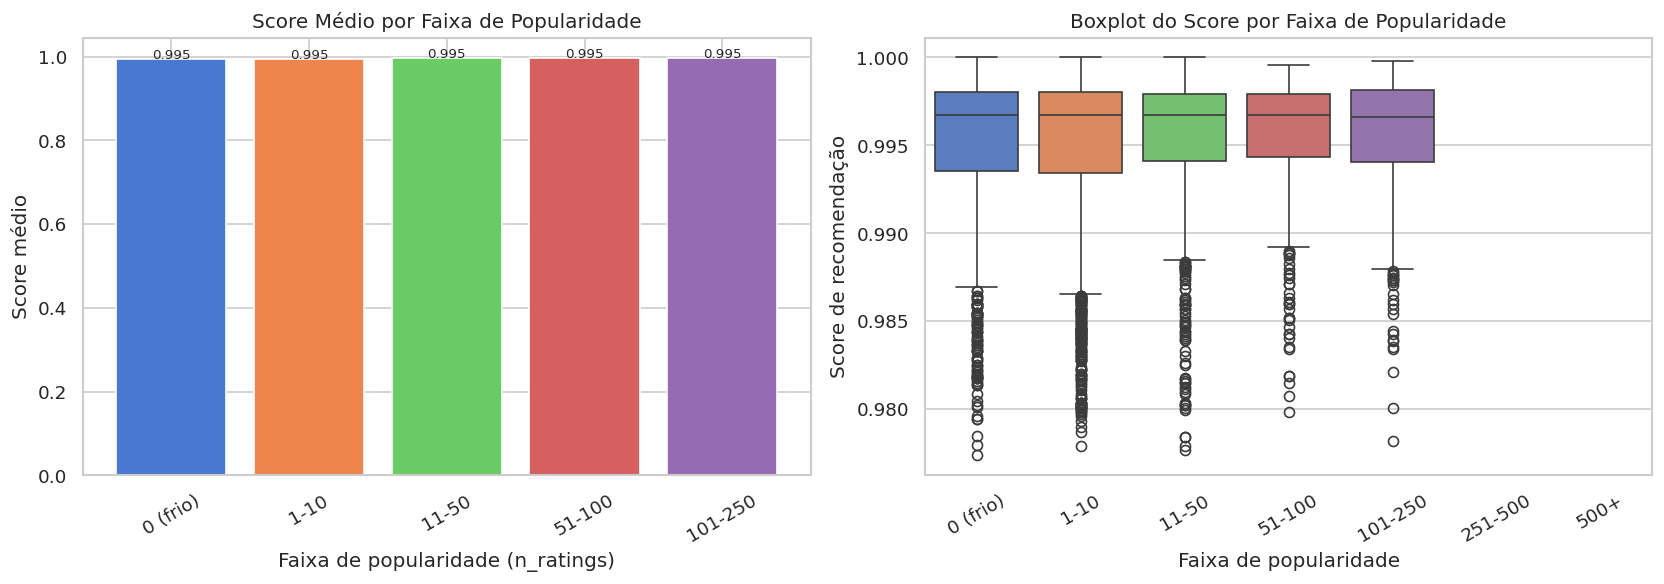

            score_médio  score_mediana  n_recomendações
pop_bucket                                             
0 (frio)       0.995173       0.996704             1386
1-10           0.995160       0.996704             2874
11-50          0.995428       0.996704             1117
51-100         0.995369       0.996704              354
101-250        0.995379       0.996601              349


In [46]:
# Score médio por faixa de popularidade
rec_full['pop_bucket'] = pd.cut(
    rec_full['n_ratings'].fillna(0), bins=bins, labels=labels
)

score_by_pop = rec_full.groupby('pop_bucket', observed=True)['score_recomendacao'].agg(['mean','median','count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Média do score por faixa
axes[0].bar(score_by_pop.index.astype(str), score_by_pop['mean'],
            color=sns.color_palette('muted', len(score_by_pop)))
axes[0].set_title('Score Médio por Faixa de Popularidade')
axes[0].set_xlabel('Faixa de popularidade (n_ratings)')
axes[0].set_ylabel('Score médio')
axes[0].tick_params(axis='x', rotation=30)
for i, (idx, row) in enumerate(score_by_pop.iterrows()):
    axes[0].text(i, row['mean'] + 0.001, f"{row['mean']:.3f}", ha='center', fontsize=8)

# Boxplot do score por faixa
plot_data = rec_full[rec_full['pop_bucket'].notna()]
sns.boxplot(
    data=plot_data, x='pop_bucket', y='score_recomendacao',
    order=labels, palette='muted', ax=axes[1]
)
axes[1].set_title('Boxplot do Score por Faixa de Popularidade')
axes[1].set_xlabel('Faixa de popularidade')
axes[1].set_ylabel('Score de recomendação')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(score_by_pop.rename(columns={'mean':'score_médio','median':'score_mediana','count':'n_recomendações'}).to_string())

---
## 5. Gêneros das Recomendações

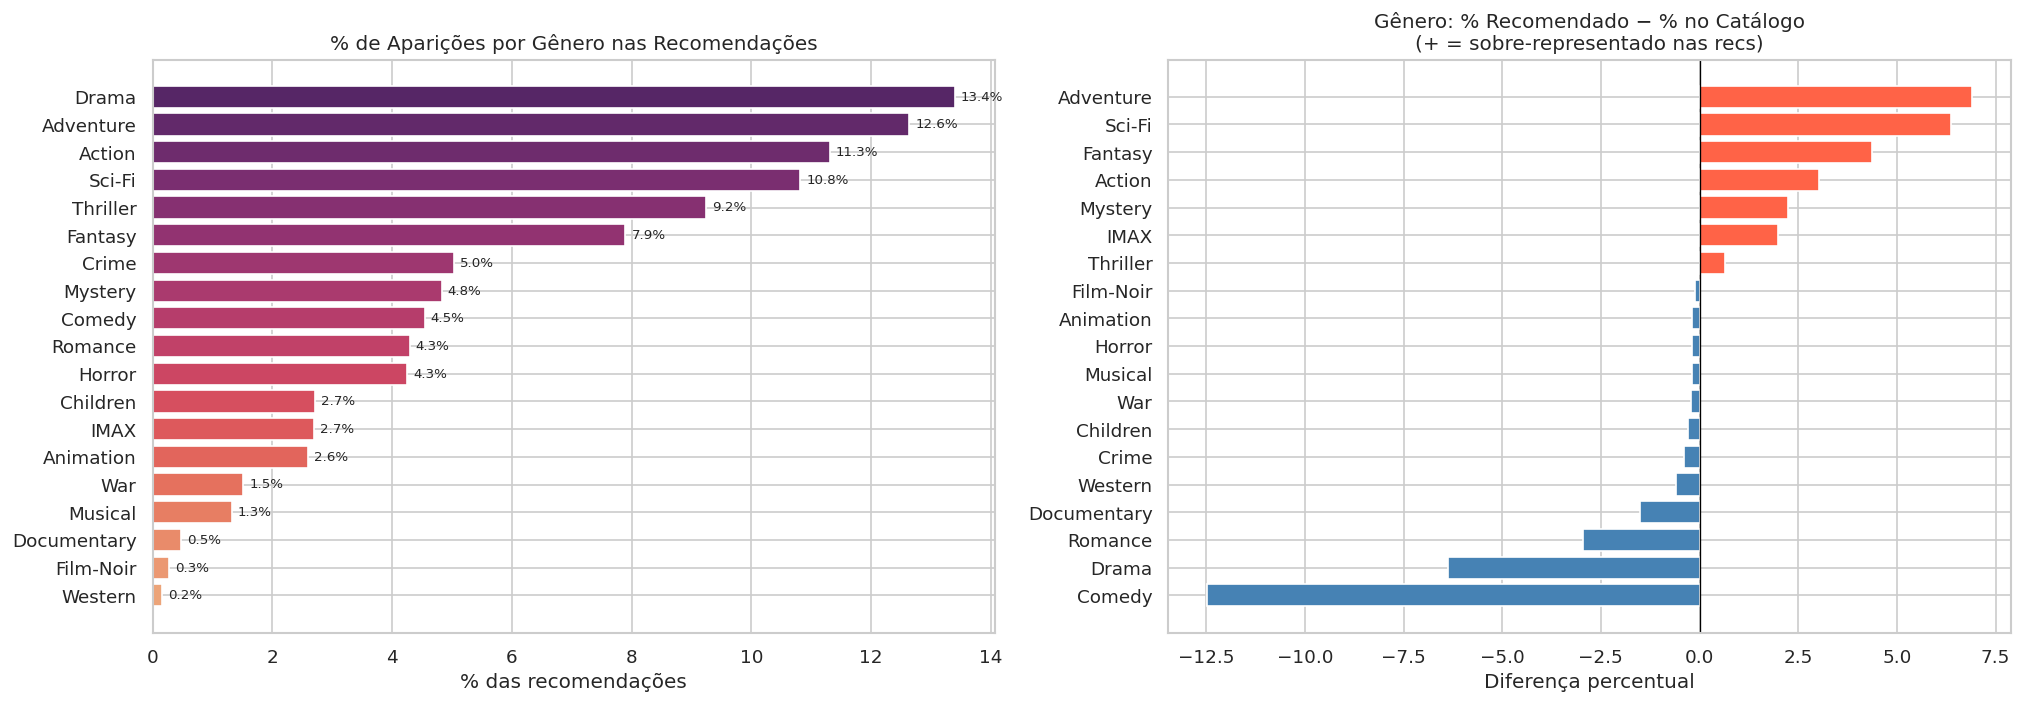

In [47]:
# 5.1 Gêneros mais recomendados (por aparição nas recomendações)
genre_rec_count = rec_genres.groupby('genre')['userId'].count().sort_values(ascending=False)

# Gêneros no catálogo completo para comparação
cbf_genres_exp = cbf.dropna(subset=['genres']).copy()
cbf_genres_exp = cbf_genres_exp.assign(genre=cbf_genres_exp['genres'].str.split('|')).explode('genre')
cbf_genres_exp['genre'] = cbf_genres_exp['genre'].str.strip()
genre_cat_count = cbf_genres_exp.groupby('genre')['movie_id'].count()

compare_df = pd.DataFrame({
    'recomendados': genre_rec_count,
    'catalogo': genre_cat_count
}).fillna(0)
compare_df['rec_pct'] = compare_df['recomendados'] / compare_df['recomendados'].sum() * 100
compare_df['cat_pct'] = compare_df['catalogo'] / compare_df['catalogo'].sum() * 100
compare_df['diferenca'] = compare_df['rec_pct'] - compare_df['cat_pct']
compare_df = compare_df.sort_values('recomendados', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Barras: recomendados
bars = axes[0].barh(
    compare_df.index[::-1], compare_df['rec_pct'][::-1],
    color=sns.color_palette('flare', len(compare_df))
)
axes[0].set_title('% de Aparições por Gênero nas Recomendações', fontsize=12)
axes[0].set_xlabel('% das recomendações')
for bar, val in zip(bars, compare_df['rec_pct'][::-1]):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=8)

# Diferença relativa ao catálogo
diff_sorted = compare_df['diferenca'].sort_values()
colors_diff = ['tomato' if v > 0 else 'steelblue' for v in diff_sorted]
axes[1].barh(diff_sorted.index, diff_sorted.values, color=colors_diff)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Gênero: % Recomendado − % no Catálogo\n(+ = sobre-representado nas recs)', fontsize=12)
axes[1].set_xlabel('Diferença percentual')

plt.tight_layout()
plt.show()

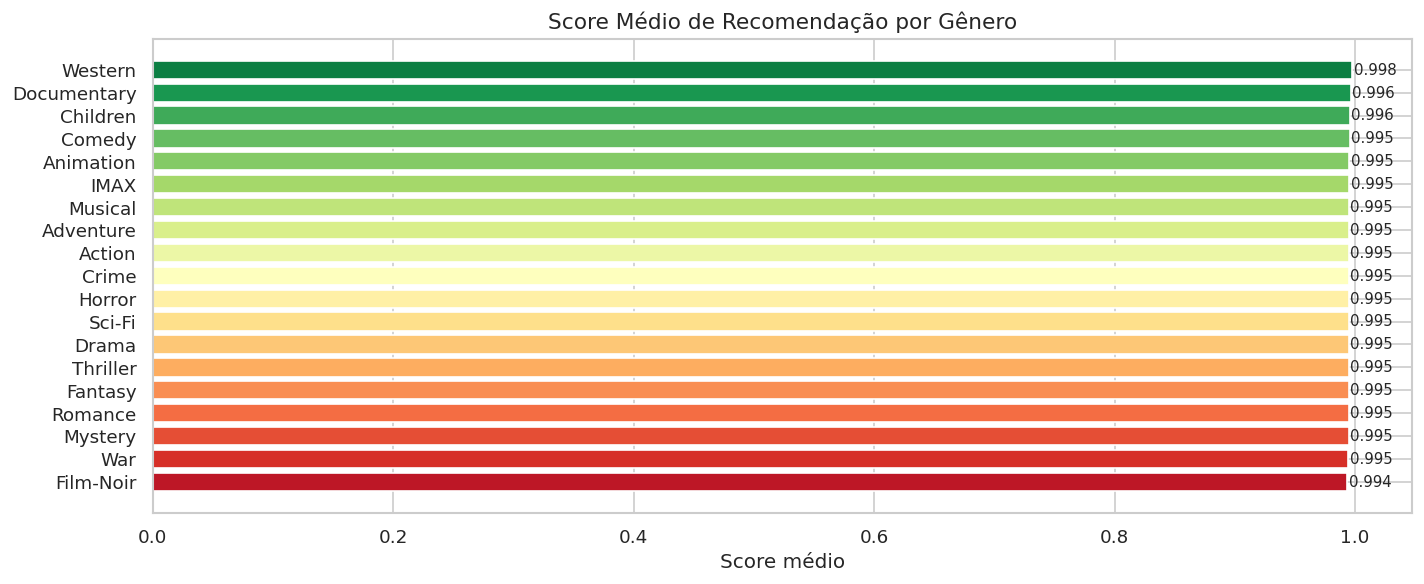

In [48]:
# 5.2 Score médio por gênero recomendado
genre_score = (
    rec_genres.groupby('genre')['score_recomendacao']
    .agg(mean='mean', count='count')
    .query('count >= 20')
    .sort_values('mean', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('RdYlGn', len(genre_score))
bars = ax.barh(genre_score.index[::-1], genre_score['mean'][::-1], color=palette)
ax.set_title('Score Médio de Recomendação por Gênero', fontsize=13)
ax.set_xlabel('Score médio')
for bar, val in zip(bars, genre_score['mean'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Diversidade das Recomendações por Usuário

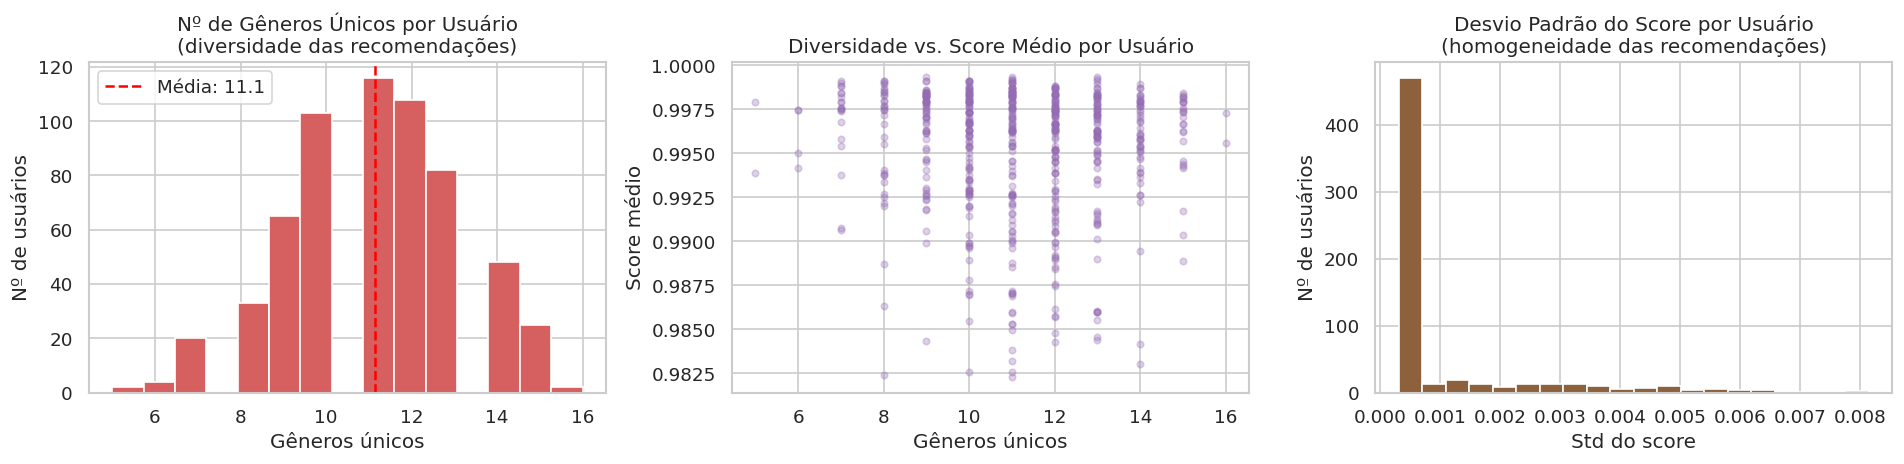

Diversidade média (gêneros únicos/usuário): 11.13
Usuários com apenas 1 gênero único       : 0


In [49]:
# Diversidade = nº de gêneros únicos nas recomendações de cada usuário
user_diversity = (
    rec_genres.groupby('userId')['genre']
    .nunique()
    .reset_index()
    .rename(columns={'genre': 'n_unique_genres'})
)

# Intra-list diversity: média dos scores por usuário
user_score_stats = rec_full.groupby('userId')['score_recomendacao'].agg(
    mean_score='mean', std_score='std'
).reset_index()

user_stats = user_diversity.merge(user_score_stats, on='userId')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribuição de diversidade
axes[0].hist(user_stats['n_unique_genres'], bins=15, color=sns.color_palette('muted')[3], edgecolor='white')
axes[0].axvline(user_stats['n_unique_genres'].mean(), color='red', linestyle='--',
                label=f'Média: {user_stats["n_unique_genres"].mean():.1f}')
axes[0].set_title('Nº de Gêneros Únicos por Usuário\n(diversidade das recomendações)')
axes[0].set_xlabel('Gêneros únicos')
axes[0].set_ylabel('Nº de usuários')
axes[0].legend()

# Diversidade vs. score médio
axes[1].scatter(user_stats['n_unique_genres'], user_stats['mean_score'],
                alpha=0.3, s=15, color=sns.color_palette('muted')[4])
axes[1].set_title('Diversidade vs. Score Médio por Usuário')
axes[1].set_xlabel('Gêneros únicos')
axes[1].set_ylabel('Score médio')

# Score std (variação dentro das recomendações do usuário)
axes[2].hist(user_stats['std_score'].dropna(), bins=20, color=sns.color_palette('muted')[5], edgecolor='white')
axes[2].set_title('Desvio Padrão do Score por Usuário\n(homogeneidade das recomendações)')
axes[2].set_xlabel('Std do score')
axes[2].set_ylabel('Nº de usuários')

plt.tight_layout()
plt.show()

print(f"Diversidade média (gêneros únicos/usuário): {user_stats['n_unique_genres'].mean():.2f}")
print(f"Usuários com apenas 1 gênero único       : {(user_stats['n_unique_genres'] == 1).sum()}")

---
## 7. Análise Temporal — Ano de Lançamento dos Filmes Recomendados

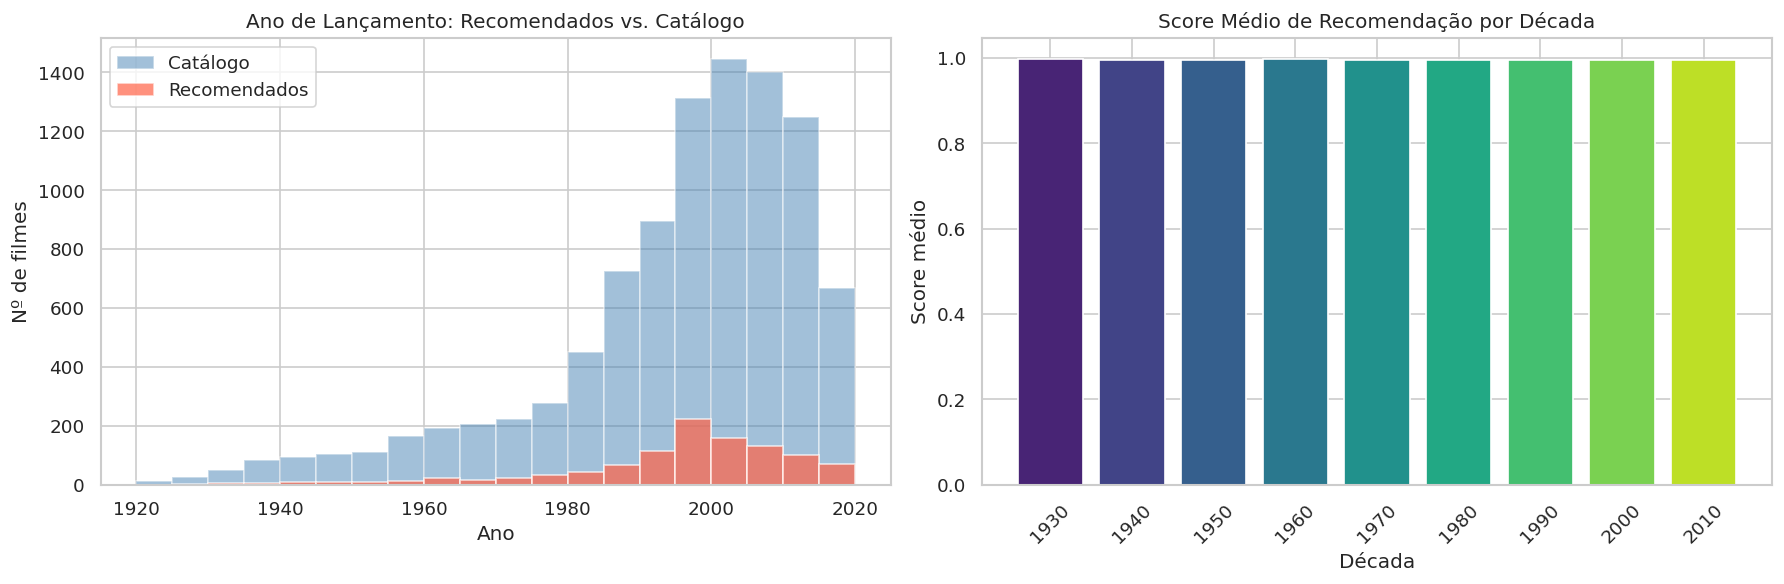

Ano mediano dos filmes recomendados : 1998
Ano mediano do catálogo completo    : 1999


In [50]:
rec_full['year'] = pd.to_numeric(rec_full['year'], errors='coerce')
catalog_pop['year'] = pd.to_numeric(catalog_pop['year'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 7.1 Distribuição do ano de lançamento — recomendados vs. catálogo
year_bins = range(1920, 2025, 5)
axes[0].hist(catalog_pop['year'].dropna(), bins=year_bins, alpha=0.5,
             label='Catálogo', color='steelblue', edgecolor='white')
axes[0].hist(rec_full.drop_duplicates('movie_id')['year'].dropna(), bins=year_bins, alpha=0.7,
             label='Recomendados', color='tomato', edgecolor='white')
axes[0].set_title('Ano de Lançamento: Recomendados vs. Catálogo')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Nº de filmes')
axes[0].legend()

# 7.2 Score médio por década
rec_full['decade'] = (rec_full['year'] // 10 * 10).astype('Int64')
score_by_decade = rec_full.groupby('decade')['score_recomendacao'].agg(['mean','count'])
score_by_decade = score_by_decade[score_by_decade['count'] >= 5]

axes[1].bar(
    score_by_decade.index.astype(str), score_by_decade['mean'],
    color=sns.color_palette('viridis', len(score_by_decade))
)
axes[1].set_title('Score Médio de Recomendação por Década')
axes[1].set_xlabel('Década')
axes[1].set_ylabel('Score médio')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Ano mediano dos filmes recomendados : {rec_full.drop_duplicates('movie_id')['year'].median():.0f}")
print(f"Ano mediano do catálogo completo    : {catalog_pop['year'].median():.0f}")

---
## 8. Qualidade das Recomendações — Notas TMDB/IMDb

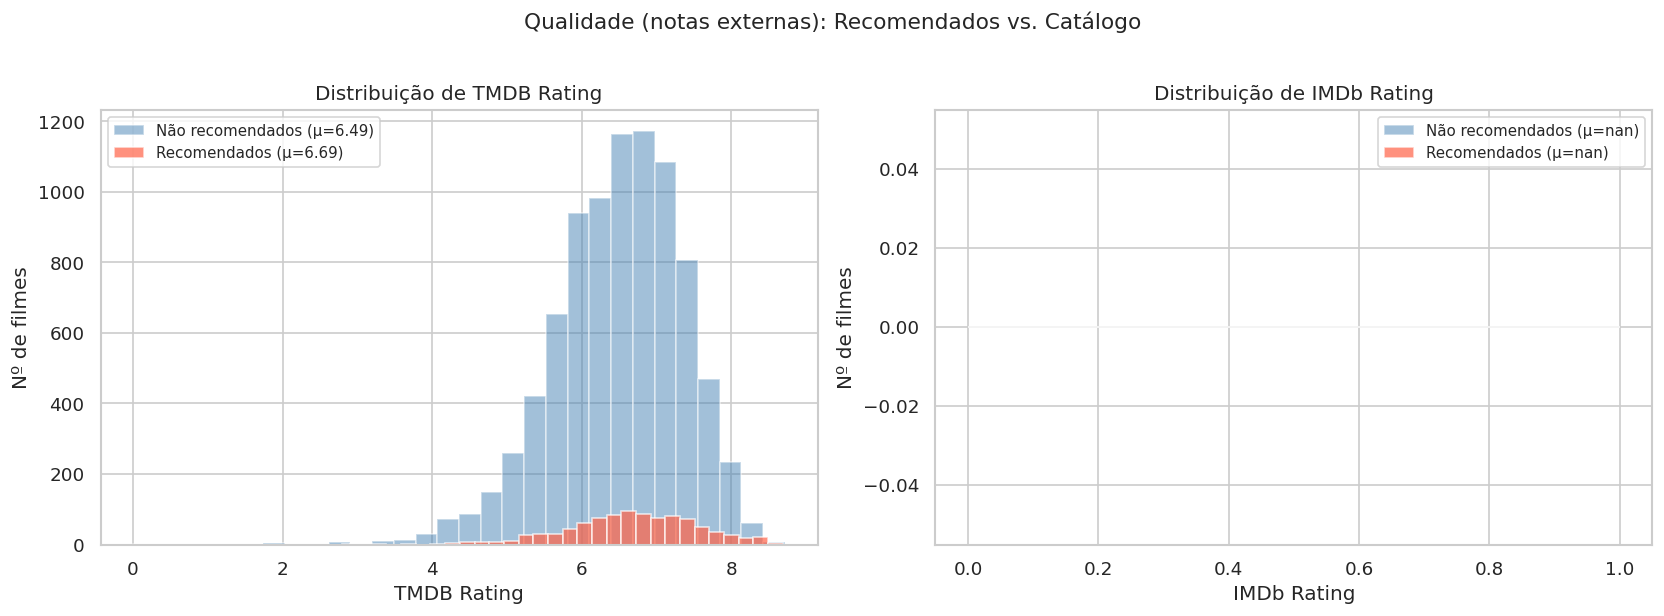

In [51]:
# Comparar tmdb_rating e imdb_rating entre recomendados e não recomendados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(axes, ['tmdb_rating', 'imdb_rating'], ['TMDB Rating', 'IMDb Rating']):
    rec_r    = catalog_pop[catalog_pop['is_recommended']][col].dropna()
    nonrec_r = catalog_pop[~catalog_pop['is_recommended']][col].dropna()
    ax.hist(nonrec_r, bins=30, alpha=0.5, label=f'Não recomendados (μ={nonrec_r.mean():.2f})',
            color='steelblue', edgecolor='white')
    ax.hist(rec_r, bins=30, alpha=0.7, label=f'Recomendados (μ={rec_r.mean():.2f})',
            color='tomato', edgecolor='white')
    ax.set_title(f'Distribuição de {label}')
    ax.set_xlabel(label)
    ax.set_ylabel('Nº de filmes')
    ax.legend(fontsize=9)

plt.suptitle('Qualidade (notas externas): Recomendados vs. Catálogo', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

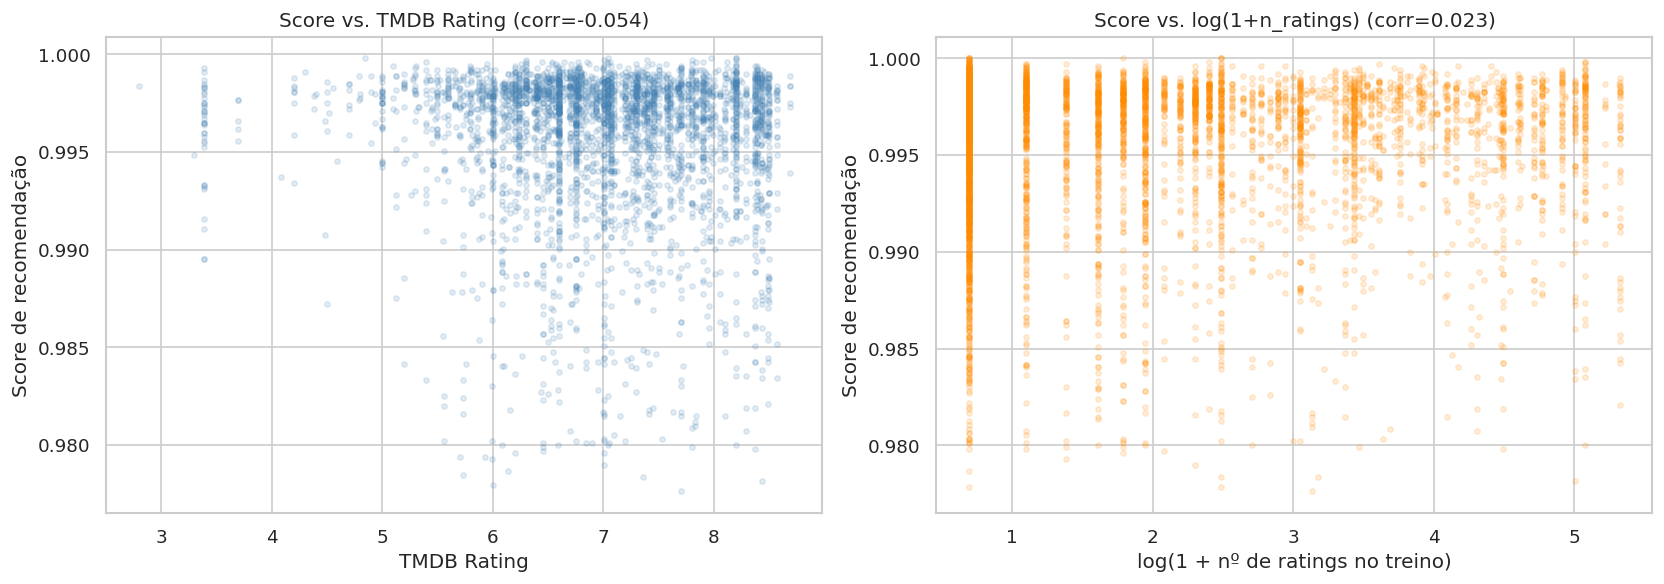

In [52]:
# Score de recomendação vs. tmdb_rating
plot_df = rec_full[rec_full['tmdb_rating'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(plot_df['tmdb_rating'], plot_df['score_recomendacao'],
                alpha=0.15, s=10, color='steelblue')
corr_tmdb = plot_df[['tmdb_rating','score_recomendacao']].corr().iloc[0,1]
axes[0].set_title(f'Score vs. TMDB Rating (corr={corr_tmdb:.3f})')
axes[0].set_xlabel('TMDB Rating')
axes[0].set_ylabel('Score de recomendação')

plot_df2 = rec_full[rec_full['n_ratings'].notna()].copy()
axes[1].scatter(np.log1p(plot_df2['n_ratings']), plot_df2['score_recomendacao'],
                alpha=0.15, s=10, color='darkorange')
corr_pop = plot_df2[['n_ratings','score_recomendacao']].corr().iloc[0,1]
axes[1].set_title(f'Score vs. log(1+n_ratings) (corr={corr_pop:.3f})')
axes[1].set_xlabel('log(1 + nº de ratings no treino)')
axes[1].set_ylabel('Score de recomendação')

plt.tight_layout()
plt.show()

---
## 9. Long-tail: Cobertura do Catálogo

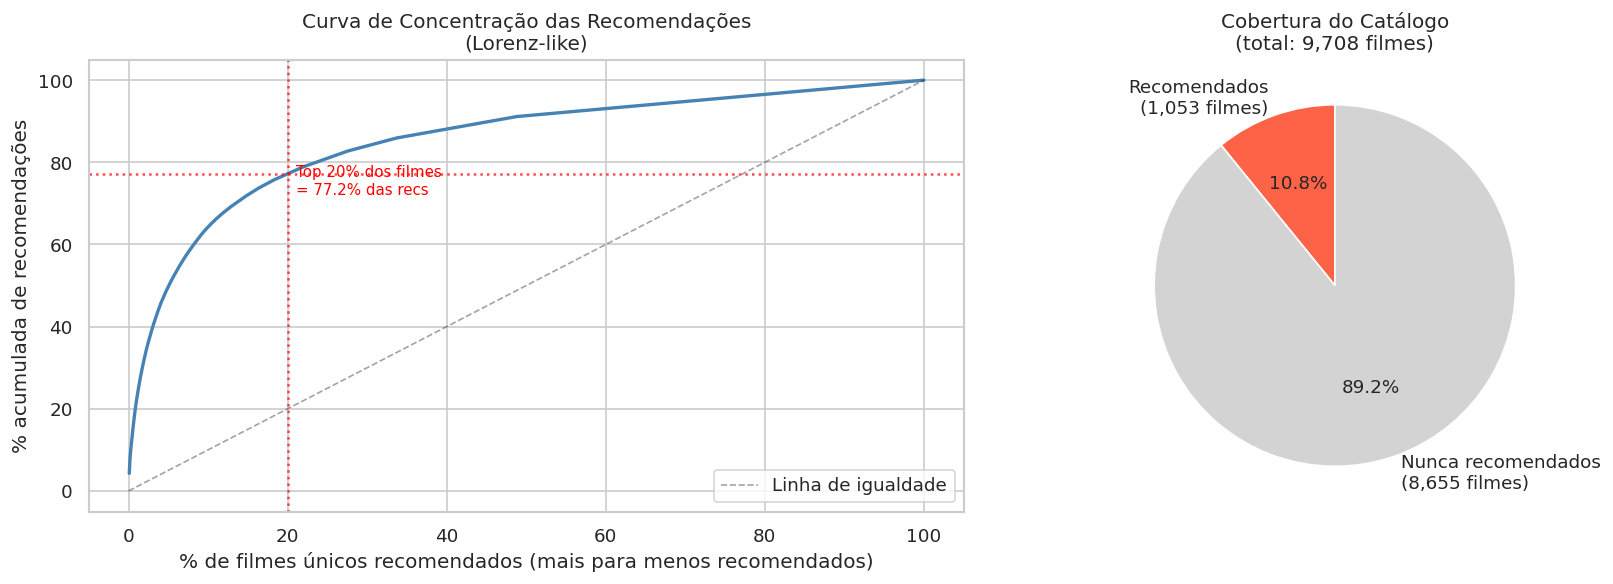

Catálogo total         : 9,708 filmes
Únicos recomendados    : 1,053 filmes (10.8% do catálogo)
Nunca recomendados     : 8,655 filmes (89.2% do catálogo)
Top 5.1% dos filmes acumulam 50% das recomendações


In [53]:
total_catalog = cbf['movie_id'].nunique()
total_rec     = rec['movie_id'].nunique()
coverage_pct  = total_rec / total_catalog * 100

# Curva de concentração: quantos filmes acumulam X% das recomendações?
freq_sorted = rec.groupby('movie_id')['userId'].count().sort_values(ascending=False)
cumulative  = freq_sorted.cumsum() / freq_sorted.sum() * 100
x_pct       = np.arange(1, len(cumulative) + 1) / len(cumulative) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Curva de concentração
axes[0].plot(x_pct, cumulative.values, color='steelblue', lw=2)
axes[0].plot([0, 100], [0, 100], 'k--', alpha=0.4, lw=1, label='Linha de igualdade')
# Marcar ponto onde top 20% dos filmes acumulam X% das recs
idx_20 = np.searchsorted(x_pct, 20)
axes[0].axvline(20, color='red', linestyle=':', alpha=0.7)
axes[0].axhline(cumulative.values[idx_20], color='red', linestyle=':', alpha=0.7)
axes[0].text(21, cumulative.values[idx_20] - 5,
             f'Top 20% dos filmes\n= {cumulative.values[idx_20]:.1f}% das recs',
             fontsize=9, color='red')
axes[0].set_title('Curva de Concentração das Recomendações\n(Lorenz-like)')
axes[0].set_xlabel('% de filmes únicos recomendados (mais para menos recomendados)')
axes[0].set_ylabel('% acumulada de recomendações')
axes[0].legend()

# Cobertura do catálogo
rec_only    = total_rec
not_covered = total_catalog - total_rec
axes[1].pie(
    [rec_only, not_covered],
    labels=[f'Recomendados\n({rec_only:,} filmes)', f'Nunca recomendados\n({not_covered:,} filmes)'],
    autopct='%1.1f%%', startangle=90,
    colors=['tomato', 'lightgray']
)
axes[1].set_title(f'Cobertura do Catálogo\n(total: {total_catalog:,} filmes)')

plt.tight_layout()
plt.show()

print(f"Catálogo total         : {total_catalog:,} filmes")
print(f"Únicos recomendados    : {total_rec:,} filmes ({coverage_pct:.1f}% do catálogo)")
print(f"Nunca recomendados     : {not_covered:,} filmes ({100-coverage_pct:.1f}% do catálogo)")
idx_50 = np.searchsorted(cumulative.values, 50)
print(f"Top {x_pct[idx_50]:.1f}% dos filmes acumulam 50% das recomendações")

---
## 10. Resumo e Diagnóstico do Modelo

In [54]:
print('=' * 65)
print('DIAGNÓSTICO DAS RECOMENDAÇÕES — RESUMO')
print('=' * 65)

# Score
print(f"\n[Score de Recomendação]")
print(f"  Média global          : {rec['score_recomendacao'].mean():.4f}")
print(f"  Mediana               : {rec['score_recomendacao'].median():.4f}")
print(f"  Mínimo                : {rec['score_recomendacao'].min():.4f}")

# Popularidade
print(f"\n[Popularidade dos filmes recomendados]")
print(f"  Média de ratings (treino)  : {rec_freq['n_ratings'].mean():.1f}")
print(f"  Mediana de ratings (treino): {rec_freq['n_ratings'].median():.1f}")
print(f"  % filmes com 0 ratings     : {(rec_freq['n_ratings'].fillna(0)==0).mean()*100:.1f}%")
print(f"  Correlação pop×freq recs   : {corr:.3f}")

# Cobertura
print(f"\n[Cobertura do catálogo]")
print(f"  Filmes cobertos       : {total_rec:,} / {total_catalog:,} ({coverage_pct:.1f}%)")

# Diversidade
print(f"\n[Diversidade de gêneros]")
print(f"  Gêneros únicos médios por usuário: {user_stats['n_unique_genres'].mean():.2f}")
print(f"  Gênero mais recomendado          : {genre_rec_count.idxmax()} ({genre_rec_count.max():,} aparições)")

# Qualidade
tmdb_rec = catalog_pop[catalog_pop['is_recommended']]['tmdb_rating'].mean()
tmdb_all = catalog_pop['tmdb_rating'].mean()
print(f"\n[Qualidade (TMDB rating)]")
print(f"  Média recomendados    : {tmdb_rec:.2f}")
print(f"  Média catálogo total  : {tmdb_all:.2f}")
delta = tmdb_rec - tmdb_all
print(f"  Diferença             : {delta:+.2f} ({'melhor' if delta > 0 else 'pior'} que a média do catálogo)")

print('\n' + '=' * 65)
print('PONTOS DE ATENÇÃO PARA AJUSTE DO MODELO')
print('=' * 65)
if corr > 0.4:
    print("  [!] Viés de popularidade detectado (corr > 0.4).")
    print("      Considere penalizar filmes muito populares no score.")
if coverage_pct < 20:
    print(f"  [!] Baixa cobertura ({coverage_pct:.1f}%): modelo recomenda sempre os mesmos filmes.")
    print("      Considere aumentar a diversidade com MMR ou penalidade de repetição.")
if user_stats['n_unique_genres'].mean() < 3:
    print("  [!] Baixa diversidade de gêneros por usuário.")
    print("      O perfil do usuário pode estar dominado por um único gênero.")
if delta < 0:
    print("  [!] Qualidade média dos recomendados abaixo do catálogo.")
    print("      Considere incorporar tmdb_rating como fator de boost.")
print('=' * 65)

DIAGNÓSTICO DAS RECOMENDAÇÕES — RESUMO

[Score de Recomendação]
  Média global          : 0.9952
  Mediana               : 0.9967
  Mínimo                : 0.9773

[Popularidade dos filmes recomendados]
  Média de ratings (treino)  : 14.7
  Mediana de ratings (treino): 4.0
  % filmes com 0 ratings     : 28.4%
  Correlação pop×freq recs   : 0.146

[Cobertura do catálogo]
  Filmes cobertos       : 1,053 / 9,708 (10.8%)

[Diversidade de gêneros]
  Gêneros únicos médios por usuário: 11.13
  Gênero mais recomendado          : Drama (2,911 aparições)

[Qualidade (TMDB rating)]
  Média recomendados    : 6.69
  Média catálogo total  : 6.51
  Diferença             : +0.18 (melhor que a média do catálogo)

PONTOS DE ATENÇÃO PARA AJUSTE DO MODELO
  [!] Baixa cobertura (10.8%): modelo recomenda sempre os mesmos filmes.
      Considere aumentar a diversidade com MMR ou penalidade de repetição.
